<a href="https://colab.research.google.com/github/Nguono-kevin/Nguono-kevin/blob/main/scikitlearn_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
my_dict = {
    'area': [2600,3000,3200,3600,4000,],
    'price': [550000,565000,610000,680000,725000],
    'shape':[42,45,21,67,98],
    'bedrooms':[2,1,3,2,5]
    }

In [25]:
import pandas as pd
df = pd.DataFrame(my_dict)
df

,area,price,shape,bedrooms
0,2600,550000,42,2
1,3000,565000,45,1
2,3200,610000,21,3
3,3600,680000,67,2
4,4000,725000,98,5


In [26]:
y = df['price']
X = df.drop('price', axis=1)

In [27]:
X.head()

,area,shape,bedrooms
0,2600,42,2
1,3000,45,1
2,3200,21,3
3,3600,67,2
4,4000,98,5


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
X_test

,area,shape,bedrooms
1,3000,45,1


In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [31]:
X_train

,area,shape,bedrooms
4,4000,98,5
2,3200,21,3
0,2600,42,2
3,3600,67,2


In [32]:
model.predict([[200,30,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([260372.09302326])

In [33]:
model.predict([[4900,40,5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([812670.54263566])

In [34]:
model.predict(X_test)

array([604333.33333333])

In [35]:
model.score(X_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

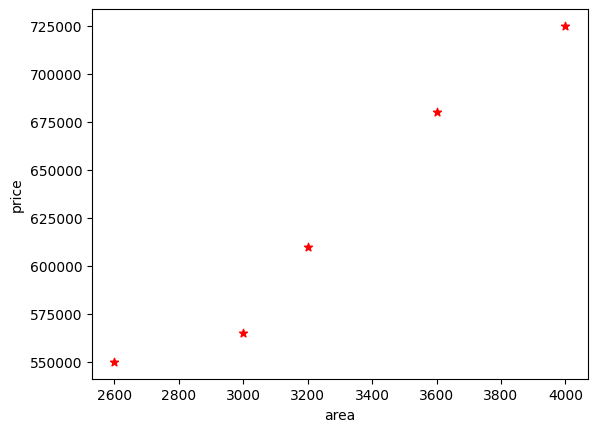

In [36]:
import matplotlib.pyplot as plt

plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area, df.price, marker="*",color="r")

plt.show()

In [37]:
d = {
    'age':[22,25,47,52,46],
    'bought_insurance':[0,0,1,0,1]
}

dff = pd.DataFrame(d)

dff

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


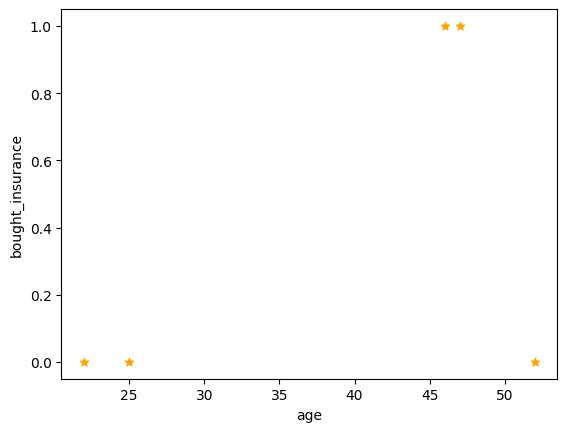

In [38]:
plt.xlabel('age')
plt.ylabel('bought_insurance')
plt.scatter(dff.age,dff.bought_insurance, marker='*', color='orange')

plt.show()

In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(dff[['age']],dff.bought_insurance,test_size=0.2,random_state = 20)

In [40]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(n_jobs=4)
model.fit(X_train,y_train)

LogisticRegression(n_jobs=4)

In [41]:
X_test

,age
1,25


In [42]:
model.predict(X_test)

array([0])

In [43]:
model.predict([[30]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [44]:
model.score(X_test,y_test)

1.0

In [47]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [50]:
data = load_breast_cancer()
x=data.data
y=data.target

In [51]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [53]:
configs=[
    {"C":0.01,"penalty":"l2","solver":"lbfgs"},
    {"C":0.1,"penalty":"l2","solver":"lbfgs"},
    {"C":1,"penalty":"l2","solver":"lbfgs"},
    {"C":10,"penalty":"l2","solver":"lbfgs"},
    {"C":1, "penalty":"l1","solver":"liblinear"},

]

In [56]:
# 4. Store results
results = []

# 5. Train and evaluate
for config in configs:
    model = LogisticRegression(
        C=config["C"],
        penalty=config["penalty"],
        solver=config["solver"],
        max_iter=1000
    )

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)

    results.append({
        "C": config["C"],
        "Penalty": config["penalty"],
        "Solver": config["solver"],
        "Accuracy": acc
    })


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [57]:
 #Print all results
print("All Results:")
for r in results:
    print(f"C={r['C']}, Penalty={r['Penalty']}, Solver={r['Solver']} -> Accuracy={r['Accuracy']:.4f}")

# 7. Get best configuration

All Results:
C=0.01, Penalty=l2, Solver=lbfgs -> Accuracy=0.9649
C=0.1, Penalty=l2, Solver=lbfgs -> Accuracy=0.9649
C=1, Penalty=l2, Solver=lbfgs -> Accuracy=0.9561
C=10, Penalty=l2, Solver=lbfgs -> Accuracy=0.9561
C=1, Penalty=l1, Solver=liblinear -> Accuracy=0.9561


In [59]:
# 7. Get best configuration
best = max(results, key=lambda x: x["Accuracy"])
print("\nBest Configuration:")
print(best)


Best Configuration:
{'C': 0.01, 'Penalty': 'l2', 'Solver': 'lbfgs', 'Accuracy': 0.9649122807017544}


In [60]:
# 8. Train final model using best config
final_model = LogisticRegression(
    C=best["C"],
    penalty=best["Penalty"],
    solver=best["Solver"],
    max_iter=1000
)

final_model.fit(X_train, y_train)

print("\nFinal model trained successfully ✅")


Final model trained successfully ✅


In [64]:
from sklearn.metrics import confusion_matrix

# After predictions
cm = confusion_matrix(y_test, predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[39  4]
 [ 1 70]]


In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, predictions, average='weighted')
recall = recall_score(y_test, predictions, average='weighted')
f1 = f1_score(y_test, predictions, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.9569049312470365
Recall: 0.956140350877193
F1-score: 0.9558014271241044


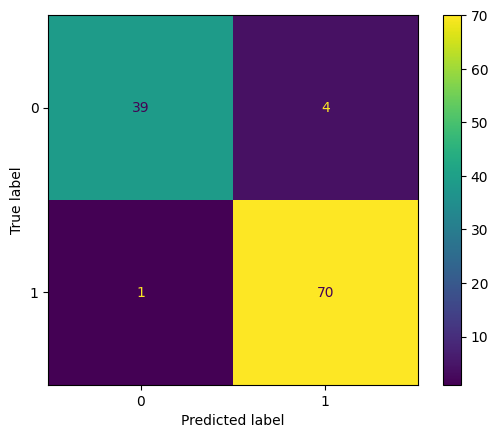

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.show()